# Layer 3 in practice: the galaxy registries

This notebook executes the material of {doc}`../layer3_galaxies`: the thirteen
occupations and the two conditional luminosity functions at their defaults, the
naming of their widths, and the seven stellar-mass relations with the derivative
their inversion keeps.
It runs on a `pip install` of `ggah_mod` plus `matplotlib`.
Layer 3 is work in progress, and the notice it emits on import is silenced below.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # before the first ggah_mod import

import inspect
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.special import erfc

import ggah_mod
warnings.filterwarnings("ignore", category=ggah_mod.WorkInProgressWarning)

import ggah_mod.sectors as S
from ggah_mod import DIFFERENTIABLE
from ggah_mod.cosmology import PLANCK18, make_pk
from ggah_mod.halos.field import make_field
from ggah_mod.sectors import clf as C, occupation as O, sham as SH

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (6.4, 4.0),
                     "axes.grid": True, "grid.alpha": 0.3})
print(f"ggah_mod {ggah_mod.__version__}, jax {jax.__version__}")

ggah_mod 1.2.0, jax 0.10.2


## The field

An occupation is evaluated on the mass grid of a layer-2 field, which every
tracer shares. The redshift, $z = 0.2$, is the one the paper draws layer 3 at;
none of the occupations depends on it.

In [2]:
field = make_field(PLANCK18, DIFFERENTIABLE, make_pk("emu_pk"), z=0.2)
m = np.asarray(field.m)
ok = (m > 3e10) & (m < 3e15)
print(f"{m.size} masses, {m[0]:.0e} to {m[-1]:.0e} h^-1 Msun")

256 masses, 1e+10 to 1e+16 h^-1 Msun


## The registry at its defaults

(a) $\langle N_{\rm c}\rangle$ and (b) $\langle N_{\rm s}\rangle$ for the thirteen
occupations, each through `GalaxySector` at `galaxy_defaults`; (c) the two
conditional luminosity functions, whose satellites are the closed form of the
incomplete gamma function rather than a quadrature.
Each model was fitted to a different survey with a different selection, and the
registry records both (printed beside each), so the spread is not a disagreement
to reconcile. The centrals of the binned model, `vanuitert16`, saturate below
one by construction.
Only the `zumandelbaum` defaults are a complete fit; the layer page says what the
other defaults are.

model                N_cen(1e13) N_sat(1e14)  z range, selection
zheng07                   1.0000     39.7476  0-0.25, luminosity threshold
kravtsov04                0.5000      0.7272  0-1, mass threshold


lange25                   0.5000      0.7289  0.1-1.1, magnitude- or colour-selected tracer sample
more15                    0.4530      0.8927  0.4-0.7, stellar-mass threshold, incomplete
more15_const              0.0812      0.0988  0-2, threshold with a constant duty cycle


guo18                     1.0000     10.0000  0.15-0.43, stellar-mass, incomplete CSMF
guo19                     0.0455      0.0939  0.6-1.1, star-forming, incomplete CSMF


zumandelbaum15            0.7106      7.0339  0.05-0.18, stellar-mass threshold; fitted as eight bins, each N(>lo) - N(>hi)
zumandelbaum16_red        0.6158      5.9622  0.05-0.18, stellar-mass threshold, red


zumandelbaum16_blue       0.0949      1.0717  0.05-0.18, stellar-mass threshold, blue
leauthaud12               1.0000     46.8460  0.22-1, stellar-mass threshold


zacharegkas25             1.0000     38.8557  0.2-1, stellar-mass bin or threshold
vanuitert16               0.0000     45.0785  0-0.5, stellar-mass bin (CSMF)


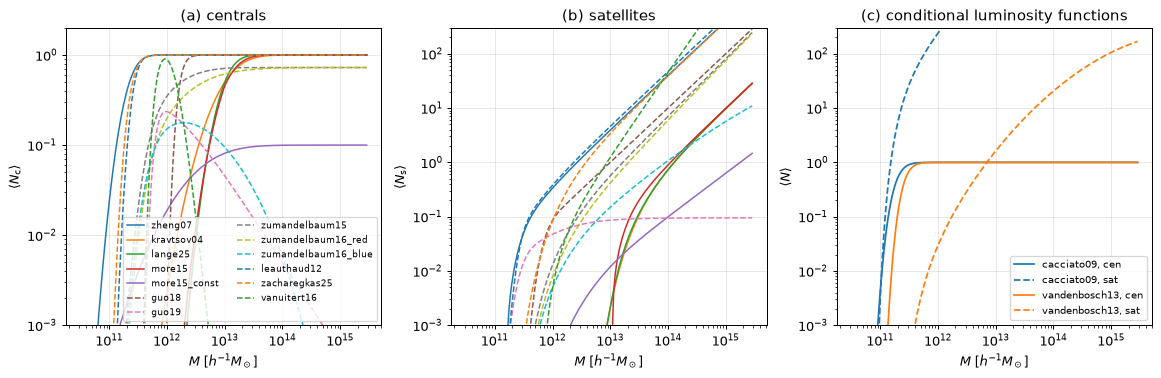

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13.0, 4.3))
lgm = np.log10(m)

print(f"{'model':20s}{'N_cen(1e13)':>12s}{'N_sat(1e14)':>12s}  z range, selection")
for i, name in enumerate(O.OCCUPATION):
    n_c, n_s = S.GalaxySector(name).occupation(field, S.galaxy_defaults(name))
    n_c, n_s = np.asarray(n_c), np.asarray(n_s)
    colour, ls = f"C{i % 10}", "-" if i < 5 else "--"
    ax[0].loglog(m[ok], n_c[ok], color=colour, ls=ls, lw=1.2, label=name)
    ax[1].loglog(m[ok], n_s[ok], color=colour, ls=ls, lw=1.2)
    cal = O.OCC_CALIBRATION[name]
    print(f"{name:20s}{np.interp(13.0, lgm, n_c):12.4f}{np.interp(14.0, lgm, n_s):12.4f}"
          f"  {cal.z_range[0]:g}-{cal.z_range[1]:g}, {cal.selection}")

for i, name in enumerate(C.CLF):
    n_c, n_s = S.GalaxySector(name).occupation(field, S.galaxy_defaults(name))
    ax[2].loglog(m[ok], np.asarray(n_c)[ok], color=f"C{i}", lw=1.4, label=f"{name}, cen")
    ax[2].loglog(m[ok], np.asarray(n_s)[ok], color=f"C{i}", ls="--", lw=1.4,
                 label=f"{name}, sat")

ax[0].set(xlabel=r"$M\ [h^{-1}M_\odot]$", ylabel=r"$\langle N_{\rm c}\rangle$",
          ylim=(1e-3, 2.0), title="(a) centrals")
ax[1].set(xlabel=r"$M\ [h^{-1}M_\odot]$", ylabel=r"$\langle N_{\rm s}\rangle$",
          ylim=(1e-3, 3e2), title="(b) satellites")
ax[2].set(xlabel=r"$M\ [h^{-1}M_\odot]$", ylabel=r"$\langle N\rangle$",
          ylim=(1e-3, 3e2), title="(c) conditional luminosity functions")
ax[0].legend(fontsize=7, loc="lower right", ncol=2)
ax[2].legend(fontsize=8, loc="lower right")
fig.tight_layout()

## Three sigmas, and a fourth

Four registry functions take a width with four different meanings, and the
parameters are named apart so that a fit cannot swap them silently. A $1\sigma$
offset in the two `erfc` conventions is a factor two in the central occupation,
and a model function refuses a width it does not take.

In [4]:
print(f"1/2 erfc(1)        = {float(0.5 * erfc(1.0)):.4f}   (sigma_logm: the erf width)")
print(f"1/2 erfc(1/sqrt 2) = {float(0.5 * erfc(1.0 / np.sqrt(2.0))):.4f}   (a Gaussian sigma)")

try:
    O.n_cen_zheng07(np.log10(m), log10mmin=11.35, sigma_lnmstar=0.25)
except TypeError as err:
    print("refused:", err)

1/2 erfc(1)        = 0.0786   (sigma_logm: the erf width)
1/2 erfc(1/sqrt 2) = 0.1587   (a Gaussian sigma)
refused: n_cen_zheng07() got an unexpected keyword argument 'sigma_lnmstar'


## Seven relations, and the gradient the inversion keeps

(a) The seven stellar-mass relations of the registry at $z = 0$, at their
published parameters, each converted from its paper's units to
$h^{-1}{\rm M}_\odot$ with `halo_mass_to_relation` and `stellar_mass_to_msun`;
`zu15` and `leauthaud12`, written backwards, are evaluated through the
bracket-and-Newton inverse. (b) The derivative of `zu15` with respect to its
shape parameter $\beta$, three ways. A bare bisection returns *exactly zero at
every mass*, since it depends on its inputs only through the sign of a residual,
while its value is correct to machine precision. Bracketing under a
`stop_gradient` and taking one Newton step leaves the value unchanged and
recovers the implicit-function derivative, which agrees with a central
difference. A forecast that varies this parameter through the bisection inherits
a column of zeros in its information matrix and reads it as infinite confidence.

behroozi13       log10 M_*(1e12) = 10.400   (1e14) = 11.069   [h^-1 Msun]
girelli20        log10 M_*(1e12) = 10.600   (1e14) = 11.271   [h^-1 Msun]
kravtsov18       log10 M_*(1e12) = 10.551   (1e14) = 11.610   [h^-1 Msun]


leauthaud12      log10 M_*(1e12) = 10.536   (1e14) = 11.325   [h^-1 Msun]
moster13         log10 M_*(1e12) = 10.463   (1e14) = 11.277   [h^-1 Msun]


universemachine  log10 M_*(1e12) = 10.362   (1e14) = 11.465   [h^-1 Msun]
zu15             log10 M_*(1e12) = 10.355   (1e14) = 11.885   [h^-1 Msun]


value, Newton step against bare bisection: max |difference| = 5.3e-15
d log10 M_* / d beta at 1e13: one Newton step -0.5798, central difference -0.5798, bare bisection 0.0000
bare bisection: max |derivative| over the grid = 0.0e+00


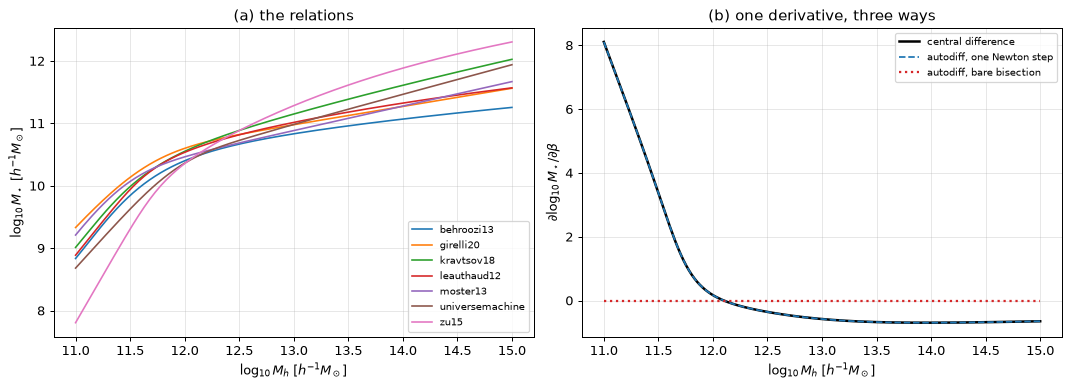

In [5]:
lm = np.linspace(11.0, 15.0, 160)                   # log10 M_h [h^-1 Msun]
h = float(PLANCK18.h)

# Published parameters for the three relations whose signature carries none:
# the two published as M_h(M_*) and Kravtsov et al. (2018).  The four
# abundance-matching fits default to their papers' values.
published = {
    "zu15": dict(lg_m1h=12.10, lg_m0star=10.31, beta=0.33, delta=0.42, gamma=1.21),
    "leauthaud12": dict(log10m1=12.520, log10m_star0=10.916, beta=0.457,
                        delta=0.566, gamma=1.53),
    "kravtsov18": dict(log10m1=11.506, log10eps=-1.632, alpha=-1.638,
                       gamma=0.596, delta=3.810),
}

fig, ax = plt.subplots(1, 2, figsize=(12.0, 4.4))
for i, name in enumerate(sorted(SH.SHMR)):
    fn = SH.make_shmr(name)
    units = SH.SHMR_MASS_UNITS[name]
    kw = dict(published.get(name, {}))
    if "h" in inspect.signature(inspect.unwrap(fn)).parameters:
        kw["h"] = h                                 # universemachine asks for it
    ms_rel = fn(SH.halo_mass_to_relation(lm, units, h), **kw)
    ms = np.asarray(SH.stellar_mass_to_msun(ms_rel, units, h)) + np.log10(h)
    ax[0].plot(lm, ms, f"C{i}", lw=1.3, label=name)
    print(f"{name:16s} log10 M_*(1e12) = {np.interp(12.0, lm, ms):6.3f}"
          f"   (1e14) = {np.interp(14.0, lm, ms):6.3f}   [h^-1 Msun]")

zm = published["zu15"]


def mstar_newton(beta):
    # The package's inverse: bracket under stop_gradient, one Newton step.
    return SH.mstar_from_mh_zu15(lm, zm["lg_m1h"], zm["lg_m0star"], beta,
                                 zm["delta"], zm["gamma"])


def mstar_bisect(beta, n=60, lo=4.0, hi=13.0):
    # A bare bisection: bracket only, no Newton step.
    def body(_, ab):
        a, b = ab
        mid = 0.5 * (a + b)
        right = SH.mh_from_mstar_zu15(mid, zm["lg_m1h"], zm["lg_m0star"], beta,
                                      zm["delta"], zm["gamma"]) < lm
        return jnp.where(right, mid, a), jnp.where(right, b, mid)

    a, b = jax.lax.fori_loop(0, n, body, (jnp.full(lm.shape, lo), jnp.full(lm.shape, hi)))
    return 0.5 * (a + b)


b0, step = zm["beta"], 1e-5
d_newton = np.asarray(jax.jacfwd(mstar_newton)(b0))
d_bisect = np.asarray(jax.jacfwd(mstar_bisect)(b0))
d_fd = (np.asarray(mstar_newton(b0 + step)) - np.asarray(mstar_newton(b0 - step))) / (2 * step)

gap = np.max(np.abs(np.asarray(mstar_newton(b0)) - np.asarray(mstar_bisect(b0))))
print(f"value, Newton step against bare bisection: max |difference| = {gap:.1e}")
print(f"d log10 M_* / d beta at 1e13: one Newton step {np.interp(13.0, lm, d_newton):.4f}, "
      f"central difference {np.interp(13.0, lm, d_fd):.4f}, "
      f"bare bisection {np.interp(13.0, lm, d_bisect):.4f}")
print(f"bare bisection: max |derivative| over the grid = {np.max(np.abs(d_bisect)):.1e}")

ax[1].plot(lm, d_fd, "k-", lw=2.0, label="central difference")
ax[1].plot(lm, d_newton, "C0--", lw=1.4, label="autodiff, one Newton step")
ax[1].plot(lm, d_bisect, "C3:", lw=1.8, label="autodiff, bare bisection")
ax[0].set(xlabel=r"$\log_{10} M_h\ [h^{-1}M_\odot]$",
          ylabel=r"$\log_{10} M_\star\ [h^{-1}M_\odot]$", title="(a) the relations")
ax[1].set(xlabel=r"$\log_{10} M_h\ [h^{-1}M_\odot]$",
          ylabel=r"$\partial \log_{10}M_\star / \partial\beta$",
          title="(b) one derivative, three ways")
ax[0].legend(fontsize=8, loc="lower right")
ax[1].legend(fontsize=8, loc="upper right")
fig.tight_layout()

## Things to try

- Swap `sigma_logm` for `sigma_lnmstar` in `S.galaxy_defaults("zheng07")` and
  read the error `S.GalaxySector("zheng07").occupation` raises.
- Differentiate `S.GalaxySector("zacharegkas25")`'s occupation at
  $10^{13}\,h^{-1}{\rm M}_\odot$ with respect to `log10m1_shmr`: its satellites
  reach that parameter only through the inverse of the Kravtsov et al. relation.
- Evaluate `C.alpha_faint_cacciato09`, defined and wired into nothing, over the
  mass grid, and compare it with the constant faint-end slope of `cacciato09`.

Previous: {doc}`../layer2_halos` and its {doc}`notebook <layer2_halos>`.